# FWI 지수 기반 산불위험 평가

FWI는 학습 모델이 아니라 기상 기반 위험 지수다. 이 노트북은 모든 결과표와 플롯을 노트북 내부 출력으로 생성한다.

## 0. 환경 설정

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False
    }
)

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
print("현재 matplotlib font.family:", plt.rcParams["font.family"])
print("현재 matplotlib font.sans-serif:", plt.rcParams["font.sans-serif"][:3])

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "data" / "학습데이터" / "학습데이터_최종_캐나다지수.csv").exists():
        PROJECT_ROOT = candidate
        break

DATA_PATH = PROJECT_ROOT / "data" / "학습데이터" / "학습데이터_최종_캐나다지수.csv"
FWI_COLUMNS = ["FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]
RANDOM_STATE = 42
TEST_SIZE = 0.3

현재 matplotlib font.family: ['Malgun Gothic']
현재 matplotlib font.sans-serif: ['Malgun Gothic']


## 1단계. 데이터 로드 및 검증

In [2]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
source_shape = df.shape
df["기준시각"] = pd.to_datetime(df["기준시각"], errors="coerce")
df["월"] = df["기준시각"].dt.month
df["연도"] = df["기준시각"].dt.year
for column in FWI_COLUMNS:
    df[column] = pd.to_numeric(df[column], errors="coerce")
df["Target"] = pd.to_numeric(df["Target"], errors="coerce").astype("int64")

required_columns = ["Target", "샘플유형", "기후지형유형", "기준시각", *FWI_COLUMNS]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"필수 컬럼 누락: {missing_columns}")

print("원본 데이터 크기:", source_shape)
print("분석용 데이터 크기(월, 연도 파생 컬럼 추가 후):", df.shape)
print("기준시각 범위:", df["기준시각"].min(), "~", df["기준시각"].max())
print("Target 1 비율:", round(df["Target"].mean(), 6))

target_distribution = df["Target"].value_counts().sort_index().rename("건수").to_frame()
target_distribution["비율"] = target_distribution["건수"] / len(df)
display(target_distribution)

sample_distribution = df["샘플유형"].value_counts().rename("건수").to_frame()
sample_distribution["비율"] = sample_distribution["건수"] / len(df)
display(sample_distribution)

validation_rows = []
for column in FWI_COLUMNS:
    values = df[column]
    finite_values = values[np.isfinite(values)]
    validation_rows.append({
        "지수": column,
        "결측": int(values.isna().sum()),
        "비유한값": int((~np.isfinite(values.dropna())).sum()),
        "음수": int((finite_values < 0).sum()),
        "최솟값": float(finite_values.min()),
        "최댓값": float(finite_values.max()),
        "평균": float(finite_values.mean()),
        "중앙값": float(finite_values.median()),
    })
validation = pd.DataFrame(validation_rows)
display(validation.round(6))

원본 데이터 크기: (17045, 68)
분석용 데이터 크기(월, 연도 파생 컬럼 추가 후): (17045, 70)
기준시각 범위: 2020-01-04 02:00:00 ~ 2021-12-31 18:00:00
Target 1 비율: 0.091112


,건수,비율
Target,,
0,15492,0.908888
1,1553,0.091112


,건수,비율
샘플유형,,
Target_0A,7738,0.453975
Target_0B1,4652,0.272925
Target_0B2,3102,0.181989
Target_1,1553,0.091112


,지수,결측,비유한값,음수,최솟값,최댓값,평균,중앙값
0,FFMC,0,0,0,1.564498,96.361814,76.265270,84.653447
1,DMC,0,0,0,0.000000,223.963807,20.165243,11.857360
2,DC,0,0,0,0.000000,1233.776116,91.469369,55.084342
3,ISI,0,0,0,0.000000,26.118217,3.619773,3.119198
4,BUI,0,0,0,0.000000,275.106192,24.349252,15.329411
5,FWI,0,0,0,0.000000,50.313772,6.522481,3.702215


## 2단계. Target별 지수 분포 EDA

FFMC                                                    DMC  \
             mean     median        std        min        max       mean   
Target                                                                     
0       75.625288  84.374656  19.271829   1.564498  96.361814  19.292730   
1       82.649428  86.557996  11.439436  15.995910  95.317723  28.869025   

                                                       DC              \
           median        std  min         max        mean      median   
Target                                                                  
0       11.024624  24.457241  0.0  223.963807   86.266333   50.203857   
1       20.174162  30.574600  0.0  218.053007  143.372411  131.016387   

                                           ISI                                \
               std  min          max      mean    median       std       min   
Target                                                                         
0       136.818656  0.0  1233.776116  3.501586  2.996890  3.015717  0.000000   
1       186.381171  0.0  1202.371116  4.798753  4.434604  3.175277  0.000033   

                         BUI                                         \
              max       mean     median        std  min         max   
Target                                                                
0       26.118217  23.185755  14.210411  31.420843  0.0  275.106192   
1       15.918733  35.955752  25.624428  41.145037  0.0  250.022006   

              FWI                                           
             mean    median       std       min        max  
Target                                                      
0        6.166944  3.375496  7.182697  0.000000  50.313772  
1       10.069155  8.276202  8.930894  0.000021  36.871187

,지수,Target0_평균,Target1_평균,평균차,평균비,Target0_중앙값,Target1_중앙값,중앙값차,Target0_Q75,Target1_Q75
0,FFMC,75.625288,82.649428,7.024140,1.092881,84.374656,86.557996,2.183340,87.545945,89.257745
1,DMC,19.292730,28.869025,9.576295,1.496368,11.024624,20.174162,9.149538,25.267066,35.374554
2,DC,86.266333,143.372411,57.106078,1.661974,50.203857,131.016387,80.812530,132.111980,181.966969
3,ISI,3.501586,4.798753,1.297167,1.370451,2.996890,4.434604,1.437714,5.216672,7.286996
4,BUI,23.185755,35.955752,12.769996,1.550769,14.210411,25.624428,11.414017,30.597312,45.085209
5,FWI,6.166944,10.069155,3.902211,1.632763,3.375496,8.276202,4.900707,9.907440,15.311520


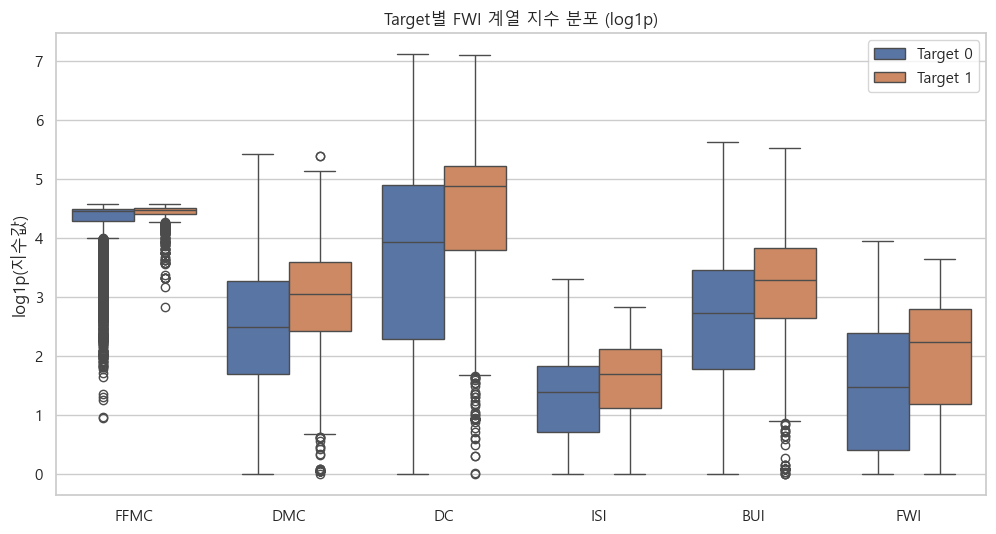

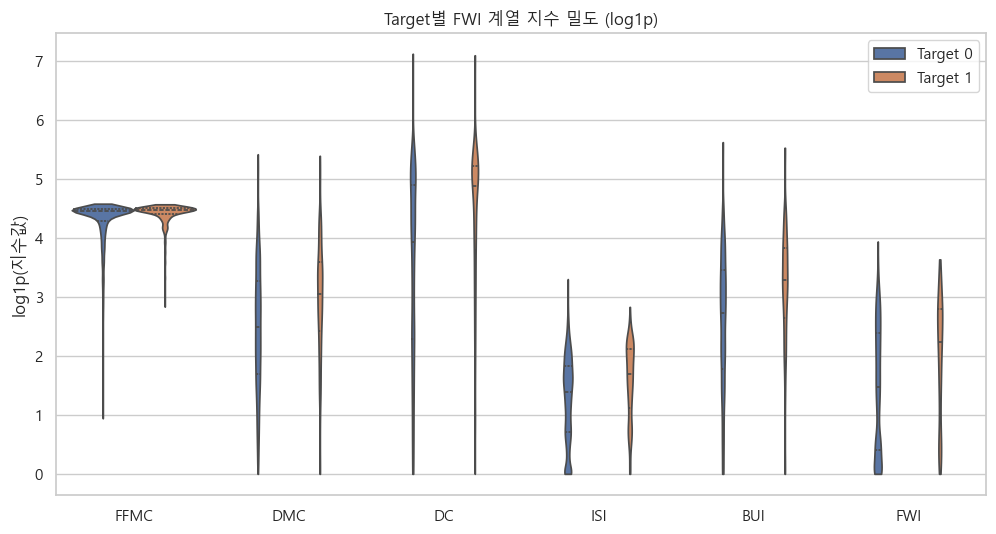

In [3]:
target_summary = df.groupby("Target")[FWI_COLUMNS].agg(["mean", "median", "std", "min", "max"])
display(target_summary.round(6))

mean_by_target = df.groupby("Target")[FWI_COLUMNS].mean()
median_by_target = df.groupby("Target")[FWI_COLUMNS].median()
q75_by_target = df.groupby("Target")[FWI_COLUMNS].quantile(0.75)
target_compare = []
for column in FWI_COLUMNS:
    target0_mean = mean_by_target.loc[0, column]
    target1_mean = mean_by_target.loc[1, column]
    target_compare.append({
        "지수": column,
        "Target0_평균": target0_mean,
        "Target1_평균": target1_mean,
        "평균차": target1_mean - target0_mean,
        "평균비": target1_mean / target0_mean,
        "Target0_중앙값": median_by_target.loc[0, column],
        "Target1_중앙값": median_by_target.loc[1, column],
        "중앙값차": median_by_target.loc[1, column] - median_by_target.loc[0, column],
        "Target0_Q75": q75_by_target.loc[0, column],
        "Target1_Q75": q75_by_target.loc[1, column],
    })
target_compare = pd.DataFrame(target_compare).round(6)
display(target_compare)

plot_df = df[["Target", *FWI_COLUMNS]].melt(id_vars="Target", var_name="지수", value_name="지수값")
plot_df["Target"] = plot_df["Target"].map({0: "Target 0", 1: "Target 1"})
plot_df["log1p_지수값"] = np.log1p(plot_df["지수값"])

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=plot_df, x="지수", y="log1p_지수값", hue="Target", ax=ax)
ax.set_title("Target별 FWI 계열 지수 분포 (log1p)")
ax.set_xlabel("")
ax.set_ylabel("log1p(지수값)")
ax.legend(title="")
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=plot_df, x="지수", y="log1p_지수값", hue="Target", cut=0, inner="quartile", ax=ax)
ax.set_title("Target별 FWI 계열 지수 밀도 (log1p)")
ax.set_xlabel("")
ax.set_ylabel("log1p(지수값)")
ax.legend(title="")
plt.show()

## 2-1단계. 점수 분위와 상위 위험구간 EDA

,지수,점수분위,건수,Target1건수,Target1비율,Lift,점수최솟값,점수최댓값
0,FFMC,1,1705,37,0.021701,0.238179,1.564498,45.513157
1,FFMC,2,1704,113,0.066315,0.727837,45.513157,66.186266
2,FFMC,3,1705,146,0.085630,0.939840,66.186266,77.431349
3,FFMC,4,1704,132,0.077465,0.850217,77.442170,82.103499
4,FFMC,5,1705,123,0.072141,0.791783,82.105115,84.653447
5,FFMC,6,1704,124,0.072770,0.798689,84.653447,86.044966
6,FFMC,7,1704,208,0.122066,1.339736,86.046168,87.136264
7,FFMC,8,1705,180,0.105572,1.158707,87.137332,88.346738
8,FFMC,9,1704,183,0.107394,1.178710,88.349718,89.956007
9,FFMC,10,1705,307,0.180059,1.976239,89.956007,96.361814


,지수,하위10%_Target1비율,상위10%_Target1비율,상위10%_Lift,상하위_비율차,분위-발생률_Spearman
5,ISI,0.021701,0.182405,2.001988,0.160704,0.869305
3,FFMC,0.021701,0.180059,1.976239,0.158358,0.854545
4,FWI,0.019941,0.171261,1.879680,0.151320,0.939394
0,BUI,0.030499,0.158944,1.744498,0.128446,0.975758
1,DC,0.028152,0.157771,1.731623,0.129619,0.911858
2,DMC,0.034604,0.157185,1.725186,0.122581,0.890909


,지수,상위비율,임계값,선택건수,Target1비율,Lift,Target1포착률
0,FFMC,0.1,89.956007,1708,0.179742,1.972768,0.197682
1,FFMC,0.2,88.347334,3409,0.143737,1.577592,0.315518
2,FFMC,0.3,87.137119,5114,0.131013,1.437936,0.431423
3,DMC,0.1,46.194318,1705,0.157185,1.725186,0.172569
4,DMC,0.2,31.800097,3410,0.128446,1.409760,0.282035
5,DMC,0.3,22.439906,5114,0.140790,1.545245,0.463619
6,DC,0.1,203.674976,1705,0.157771,1.731623,0.173213
7,DC,0.2,156.163080,3409,0.173071,1.899549,0.379910
8,DC,0.3,120.268156,5114,0.162495,1.783470,0.535093
9,ISI,0.1,7.751103,1706,0.182298,2.000815,0.200258


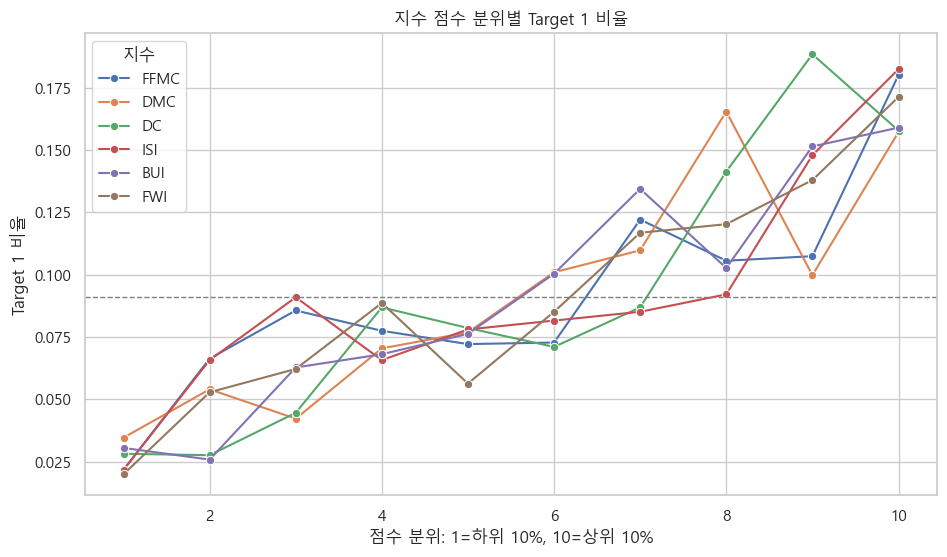

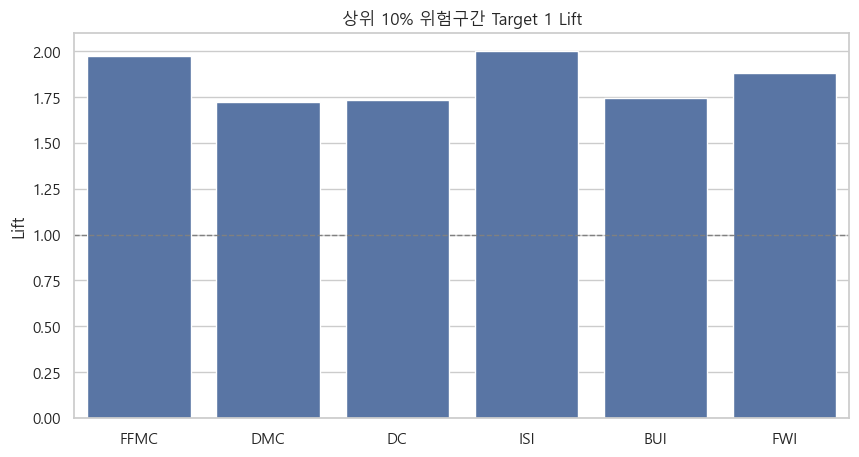

In [4]:
base_rate = df["Target"].mean()

def score_decile_table(data, score_columns):
    rows = []
    for column in score_columns:
        ranked = data[column].rank(method="first")
        decile = pd.qcut(ranked, 10, labels=range(1, 11)).astype(int)
        grouped = data.assign(점수분위=decile).groupby("점수분위", observed=True)
        for bucket, part in grouped:
            rows.append({
                "지수": column,
                "점수분위": int(bucket),
                "건수": int(part.shape[0]),
                "Target1건수": int(part["Target"].sum()),
                "Target1비율": part["Target"].mean(),
                "Lift": part["Target"].mean() / base_rate,
                "점수최솟값": part[column].min(),
                "점수최댓값": part[column].max(),
            })
    return pd.DataFrame(rows)

decile_rates = score_decile_table(df, FWI_COLUMNS)
display(decile_rates.round(6))

decile_summary = []
for column, part in decile_rates.groupby("지수"):
    ordered = part.sort_values("점수분위")
    decile_summary.append({
        "지수": column,
        "하위10%_Target1비율": ordered.iloc[0]["Target1비율"],
        "상위10%_Target1비율": ordered.iloc[-1]["Target1비율"],
        "상위10%_Lift": ordered.iloc[-1]["Lift"],
        "상하위_비율차": ordered.iloc[-1]["Target1비율"] - ordered.iloc[0]["Target1비율"],
        "분위-발생률_Spearman": ordered["점수분위"].corr(ordered["Target1비율"], method="spearman"),
    })
decile_summary = pd.DataFrame(decile_summary).sort_values("상위10%_Lift", ascending=False)
display(decile_summary.round(6))

top_quantile_rows = []
total_positive = df["Target"].sum()
for column in FWI_COLUMNS:
    for share in [0.10, 0.20, 0.30]:
        threshold = df[column].quantile(1 - share)
        selected = df[df[column] >= threshold]
        top_quantile_rows.append({
            "지수": column,
            "상위비율": share,
            "임계값": threshold,
            "선택건수": len(selected),
            "Target1비율": selected["Target"].mean(),
            "Lift": selected["Target"].mean() / base_rate,
            "Target1포착률": selected["Target"].sum() / total_positive,
        })
top_quantiles = pd.DataFrame(top_quantile_rows)
display(top_quantiles.round(6))

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=decile_rates, x="점수분위", y="Target1비율", hue="지수", marker="o", ax=ax)
ax.axhline(base_rate, color="gray", linestyle="--", linewidth=1, label=f"전체 Target1 비율={base_rate:.3f}")
ax.set_title("지수 점수 분위별 Target 1 비율")
ax.set_xlabel("점수 분위: 1=하위 10%, 10=상위 10%")
ax.set_ylabel("Target 1 비율")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_quantiles[top_quantiles["상위비율"] == 0.10], x="지수", y="Lift", ax=ax)
ax.axhline(1, color="gray", linestyle="--", linewidth=1)
ax.set_title("상위 10% 위험구간 Target 1 Lift")
ax.set_xlabel("")
ax.set_ylabel("Lift")
plt.show()

## 2-2단계. 샘플유형, 기후지형유형, 월별 EDA

,FFMC,DMC,DC,ISI,BUI,FWI
샘플유형,,,,,,
Target_0A,76.058805,19.344293,83.605181,3.572031,23.145698,6.213551
Target_0B1,76.461928,19.507920,85.732850,3.664848,23.315734,6.446073
Target_0B2,73.289185,18.841388,93.704683,3.081021,23.090755,5.632078
Target_1,82.649428,28.869025,143.372411,4.798753,35.955752,10.069155


,FFMC,DMC,DC,ISI,BUI,FWI
기후지형유형,,,,,,
고지·산간형,75.533816,14.379822,66.193246,3.557783,17.299143,5.353099
영동 해안형,77.838045,29.153645,129.830426,4.331010,36.011925,9.064361
영서 내륙형,75.330397,15.284834,70.809051,3.119579,17.885268,5.007882


DC        BUI        FWI
기후지형유형 Target                                  
고지·산간형 0        62.397980  16.548187   5.085134
       1       104.026234  24.785025   8.024306
영동 해안형 0       120.199854  33.702550   8.382998
       1       225.895809  59.048045  15.860991
영서 내륙형 0        68.425475  17.437605   4.864459
       1        94.592184  22.352018   6.438943

,건수,Target1건수,Target1비율,FWI평균,DC평균,BUI평균
월,,,,,,
1,1195,112,0.093724,5.103534,94.725813,21.519479
2,6485,698,0.107633,6.644776,114.213406,26.393834
3,1990,188,0.094472,4.242963,38.930914,12.620860
4,2394,242,0.101086,9.550944,49.426526,26.790634
5,1229,104,0.084622,5.225838,64.554994,21.151938
6,469,24,0.051173,8.501769,143.744767,44.168781
7,301,4,0.013289,3.517052,114.928225,20.244320
8,298,1,0.003356,2.030758,89.044549,13.939173
9,287,3,0.010453,2.339603,54.150104,10.410341


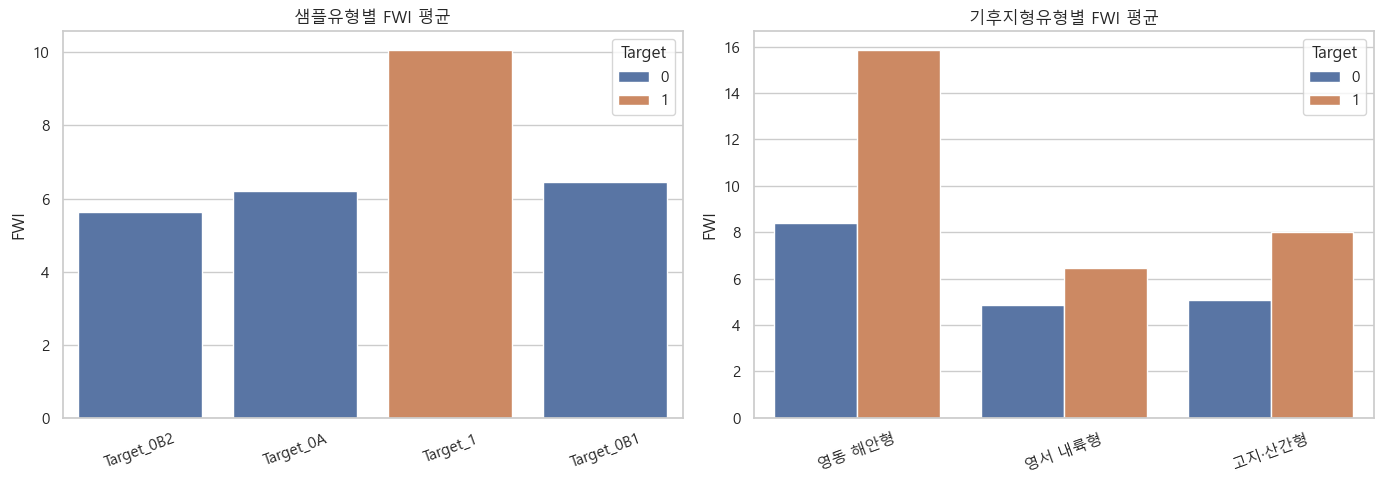

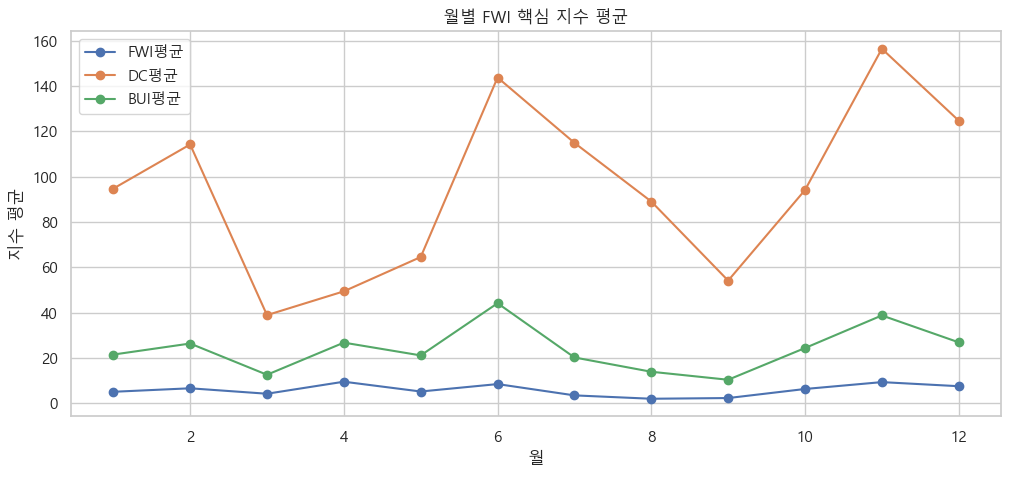

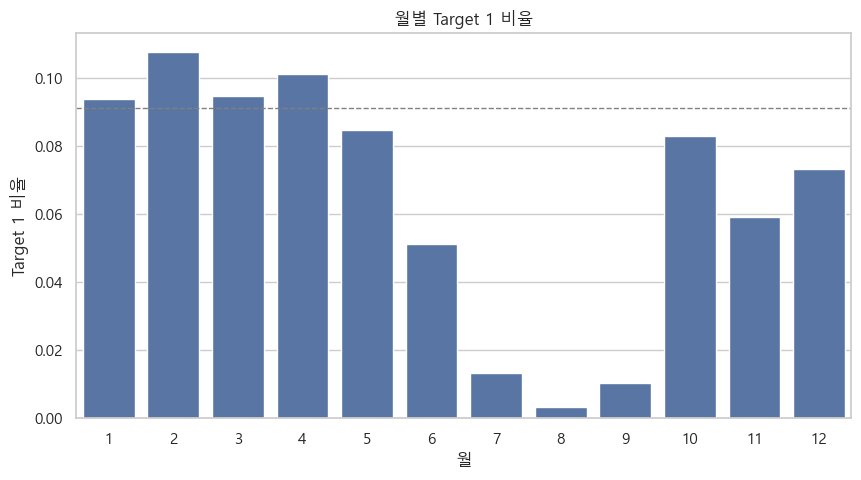

In [5]:
sample_means = df.groupby("샘플유형")[FWI_COLUMNS].mean().round(6)
climate_means = df.groupby("기후지형유형")[FWI_COLUMNS].mean().round(6)
climate_target_means = df.groupby(["기후지형유형", "Target"])[["DC", "BUI", "FWI"]].mean().round(6)
monthly_summary = (
    df.groupby("월")
    .agg(
        건수=("Target", "size"),
        Target1건수=("Target", "sum"),
        Target1비율=("Target", "mean"),
        FWI평균=("FWI", "mean"),
        DC평균=("DC", "mean"),
        BUI평균=("BUI", "mean"),
    )
    .round(6)
)

display(sample_means)
display(climate_means)
display(climate_target_means)
display(monthly_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x="샘플유형", y="FWI", hue="Target", errorbar=None, ax=axes[0])
axes[0].set_title("샘플유형별 FWI 평균")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
sns.barplot(data=df, x="기후지형유형", y="FWI", hue="Target", errorbar=None, ax=axes[1])
axes[1].set_title("기후지형유형별 FWI 평균")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 5))
monthly_summary[["FWI평균", "DC평균", "BUI평균"]].plot(ax=ax1, marker="o")
ax1.set_title("월별 FWI 핵심 지수 평균")
ax1.set_xlabel("월")
ax1.set_ylabel("지수 평균")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=monthly_summary.reset_index(), x="월", y="Target1비율", ax=ax)
ax.axhline(df["Target"].mean(), color="gray", linestyle="--", linewidth=1)
ax.set_title("월별 Target 1 비율")
ax.set_ylabel("Target 1 비율")
plt.show()

## 2-3단계. 지수 간 상관과 중복성 확인

,FFMC,DMC,DC,ISI,BUI,FWI
FFMC,1.000,0.349,0.217,0.668,0.321,0.544
DMC,0.349,1.000,0.806,0.476,0.980,0.810
DC,0.217,0.806,1.000,0.256,0.894,0.578
ISI,0.668,0.476,0.256,1.000,0.428,0.859
BUI,0.321,0.980,0.894,0.428,1.000,0.770
FWI,0.544,0.810,0.578,0.859,0.770,1.000


,FFMC,DMC,DC,ISI,BUI,FWI
FFMC,1.000,0.651,0.401,0.954,0.617,0.912
DMC,0.651,1.000,0.734,0.648,0.983,0.843
DC,0.401,0.734,1.000,0.401,0.833,0.618
ISI,0.954,0.648,0.401,1.000,0.615,0.937
BUI,0.617,0.983,0.833,0.615,1.000,0.828
FWI,0.912,0.843,0.618,0.937,0.828,1.000


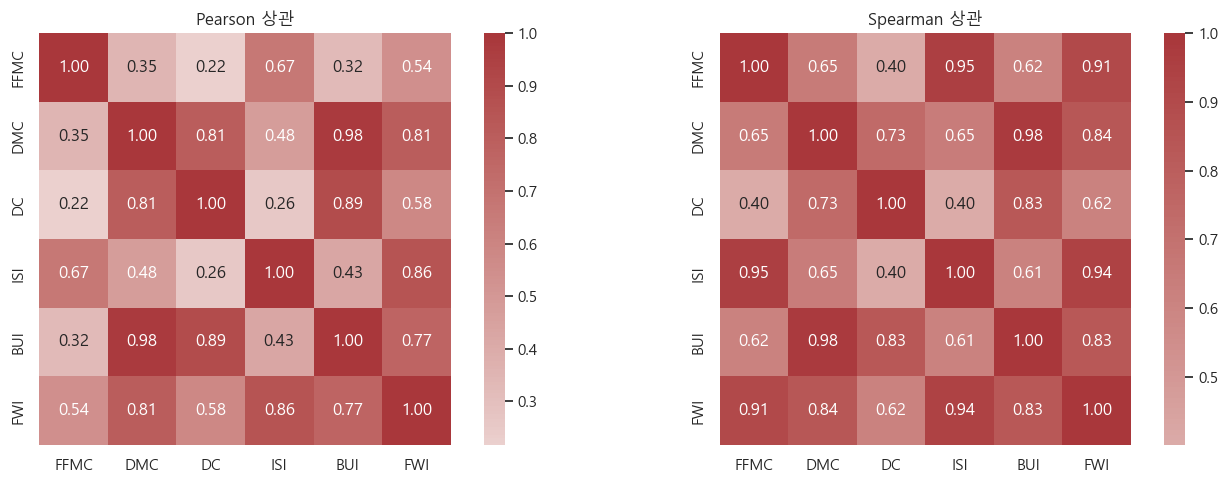

In [6]:
pearson_corr = df[FWI_COLUMNS].corr(method="pearson").round(3)
spearman_corr = df[FWI_COLUMNS].corr(method="spearman").round(3)
display(pearson_corr)
display(spearman_corr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=axes[0])
axes[0].set_title("Pearson 상관")
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=axes[1])
axes[1].set_title("Spearman 상관")
plt.tight_layout()
plt.show()

## 3단계. 지수 기반 예측 성능 평가

,지수,AUROC,AUPRC,Base_Rate,AUPRC_Base대비
0,FFMC,0.616390,0.138506,0.091122,1.520000
1,DMC,0.641466,0.134106,0.091122,1.471708
2,DC,0.671343,0.141876,0.091122,1.556979
3,ISI,0.630715,0.140168,0.091122,1.538237
4,BUI,0.655770,0.137445,0.091122,1.508358
5,FWI,0.650658,0.150029,0.091122,1.646450


,지수,임계값,Accuracy,Balanced_Accuracy,Precision,Recall,F1,TN,FP,FN,TP,예측양성비율
0,FFMC,86.525960,0.641572,0.588502,0.131536,0.523605,0.210254,3037,1611,222,244,0.362730
1,DMC,10.380451,0.504497,0.622182,0.128325,0.766094,0.219828,2223,2425,109,357,0.543997
2,DC,122.919055,0.706883,0.618639,0.157720,0.510730,0.241013,3377,1271,228,238,0.295072
3,ISI,5.031873,0.701017,0.589347,0.142088,0.452790,0.216299,3374,1274,255,211,0.290379
4,BUI,17.535039,0.577434,0.629484,0.137975,0.693133,0.230139,2630,2018,143,323,0.457763
5,FWI,3.947775,0.541064,0.605614,0.126638,0.684549,0.213735,2448,2200,147,319,0.492569


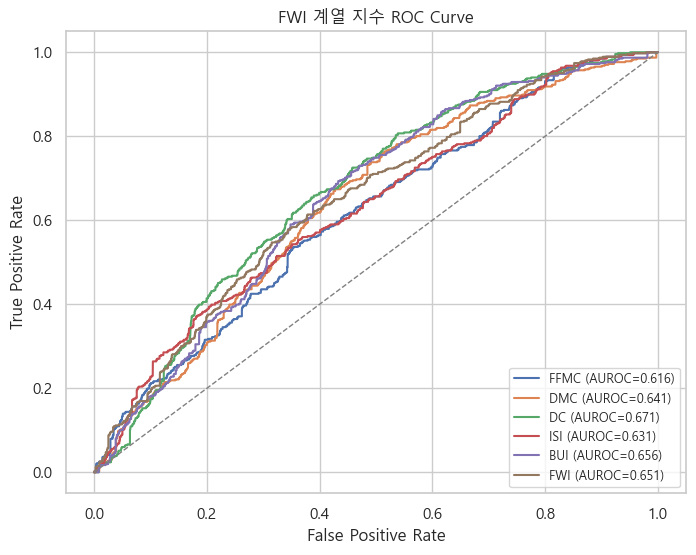

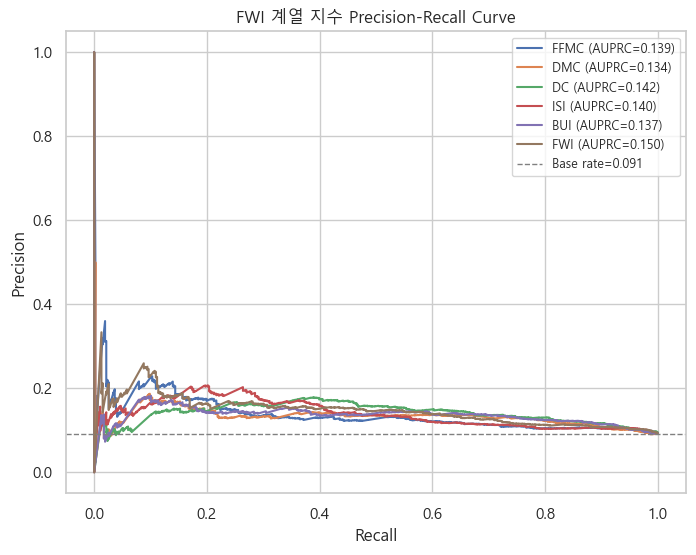

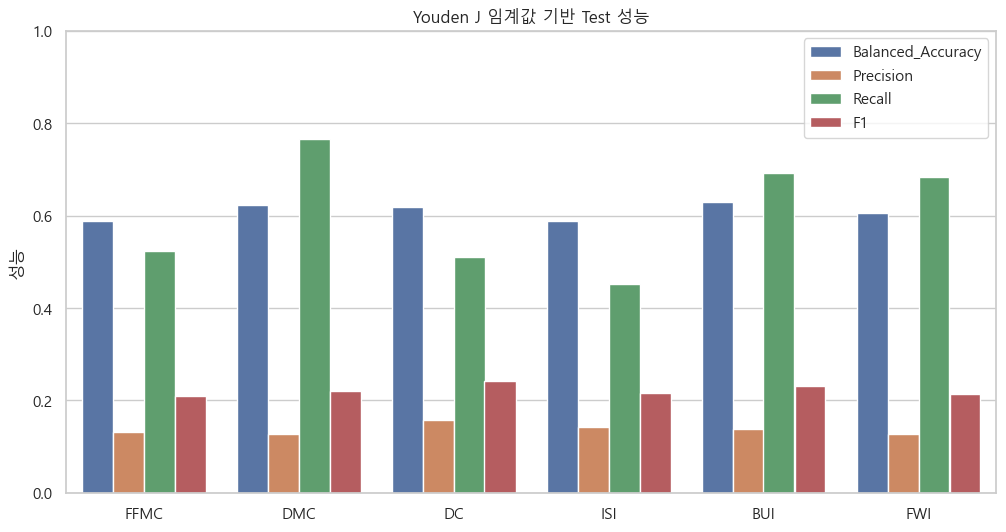

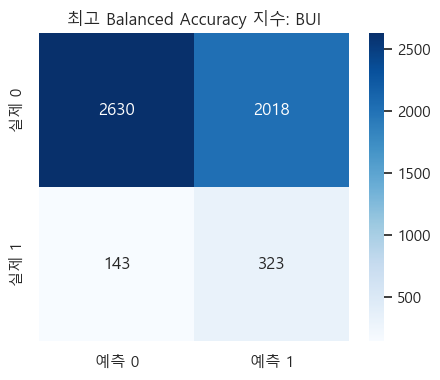

In [7]:
train, test = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["Target"],
)
y_train = train["Target"]
y_test = test["Target"]
test_base_rate = y_test.mean()

def youden_threshold(y_true, score):
    fpr, tpr, thresholds = roc_curve(y_true, score)
    finite_mask = np.isfinite(thresholds)
    finite_fpr = fpr[finite_mask]
    finite_tpr = tpr[finite_mask]
    finite_thresholds = thresholds[finite_mask]
    idx = int(np.argmax(finite_tpr - finite_fpr))
    return float(finite_thresholds[idx])

def evaluate_threshold(y_true, score, threshold):
    pred = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "임계값": threshold,
        "Accuracy": accuracy_score(y_true, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "예측양성비율": pred.mean(),
    }

score_rows = []
threshold_rows = []
thresholds = {}
for column in FWI_COLUMNS:
    threshold = youden_threshold(y_train, train[column])
    thresholds[column] = threshold
    auroc = roc_auc_score(y_test, test[column])
    auprc = average_precision_score(y_test, test[column])
    score_rows.append({
        "지수": column,
        "AUROC": auroc,
        "AUPRC": auprc,
        "Base_Rate": test_base_rate,
        "AUPRC_Base대비": auprc / test_base_rate,
    })
    threshold_rows.append({"지수": column, **evaluate_threshold(y_test, test[column], threshold)})

score_metrics = pd.DataFrame(score_rows).round(6)
threshold_metrics = pd.DataFrame(threshold_rows).round(6)
display(score_metrics)
display(threshold_metrics)

fig, ax = plt.subplots(figsize=(8, 6))
for column in FWI_COLUMNS:
    fpr, tpr, _ = roc_curve(y_test, test[column])
    auc = roc_auc_score(y_test, test[column])
    ax.plot(fpr, tpr, label=f"{column} (AUROC={auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
ax.set_title("FWI 계열 지수 ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=9)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for column in FWI_COLUMNS:
    precision, recall, _ = precision_recall_curve(y_test, test[column])
    ap = average_precision_score(y_test, test[column])
    ax.plot(recall, precision, label=f"{column} (AUPRC={ap:.3f})")
ax.axhline(test_base_rate, color="gray", linestyle="--", linewidth=1, label=f"Base rate={test_base_rate:.3f}")
ax.set_title("FWI 계열 지수 Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right", fontsize=9)
plt.show()

metric_plot = threshold_metrics.melt(
    id_vars="지수",
    value_vars=["Balanced_Accuracy", "Precision", "Recall", "F1"],
    var_name="성능지표",
    value_name="값",
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=metric_plot, x="지수", y="값", hue="성능지표", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Youden J 임계값 기반 Test 성능")
ax.set_xlabel("")
ax.set_ylabel("성능")
ax.legend(title="")
plt.show()

best_balanced_index = threshold_metrics.sort_values("Balanced_Accuracy", ascending=False).iloc[0]["지수"]
best_threshold = thresholds[best_balanced_index]
best_pred = (test[best_balanced_index] >= best_threshold).astype(int)
matrix = confusion_matrix(y_test, best_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["예측 0", "예측 1"],
    yticklabels=["실제 0", "실제 1"],
    ax=ax,
)
ax.set_title(f"최고 Balanced Accuracy 지수: {best_balanced_index}")
plt.show()

## 최종 해석

In [8]:
best_auroc = score_metrics.sort_values("AUROC", ascending=False).iloc[0]
best_auprc = score_metrics.sort_values("AUPRC", ascending=False).iloc[0]
best_balanced = threshold_metrics.sort_values("Balanced_Accuracy", ascending=False).iloc[0]
best_top10 = top_quantiles[top_quantiles["상위비율"] == 0.10].sort_values("Lift", ascending=False).iloc[0]

print(f"AUROC 최고 지수: {best_auroc['지수']} = {best_auroc['AUROC']:.6f}")
print(f"AUPRC 최고 지수: {best_auprc['지수']} = {best_auprc['AUPRC']:.6f}")
print(f"Balanced Accuracy 최고 지수: {best_balanced['지수']} = {best_balanced['Balanced_Accuracy']:.6f}")
print(f"상위 10% Lift 최고 지수: {best_top10['지수']} = {best_top10['Lift']:.6f}")

if best_auroc["AUROC"] < 0.6:
    conclusion = "단독 예측 모델로 쓰기에는 성능이 약하다."
elif best_auroc["AUROC"] < 0.7:
    conclusion = "위험도 정렬 신호는 있으나 단독 예측 모델로는 제한적이다."
else:
    conclusion = "단독 위험도 점수로도 일정 수준의 구분력이 있다."

print("최종 판단:", conclusion)
print("해석: FWI 계열 지수는 확률이 아니라 위험 점수다. 고위험 구간 선별에는 유용하지만, 단독 산불 예측 모델로 쓰기에는 Precision과 AUPRC가 낮다.")

AUROC 최고 지수: DC = 0.671343
AUPRC 최고 지수: FWI = 0.150029
Balanced Accuracy 최고 지수: BUI = 0.629484
상위 10% Lift 최고 지수: ISI = 2.000815
최종 판단: 위험도 정렬 신호는 있으나 단독 예측 모델로는 제한적이다.
해석: FWI 계열 지수는 확률이 아니라 위험 점수다. 고위험 구간 선별에는 유용하지만, 단독 산불 예측 모델로 쓰기에는 Precision과 AUPRC가 낮다.


`FWI`, `BUI`, `ISI` 등은 0~1 확률이 아니라 위험 점수다. 따라서 결과는 산불 발생확률 모델이 아니라, 위험 점수의 정렬력과 임계값 기반 분류 성능으로 해석한다.